# Marketing Campaign A/B/n Testing Analysis

## Business Problem

A fast-food company tested three different marketing promotions to determine which campaign generated the highest sales performance for a new product launch.

The objective of this analysis is to identify whether statistically significant differences exist among the promotion groups and determine the most effective promotion strategy.

# EDA

In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [2]:

df=pd.read_csv("WA_Marketing-Campaign.csv")
df

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29


In [3]:
df.Promotion.value_counts()

Promotion
3    188
2    188
1    172
Name: count, dtype: int64

In [4]:
promotion_mean_sales=df.groupby("Promotion")["SalesInThousands"].mean()
promotion_mean_sales

Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

# Visualization


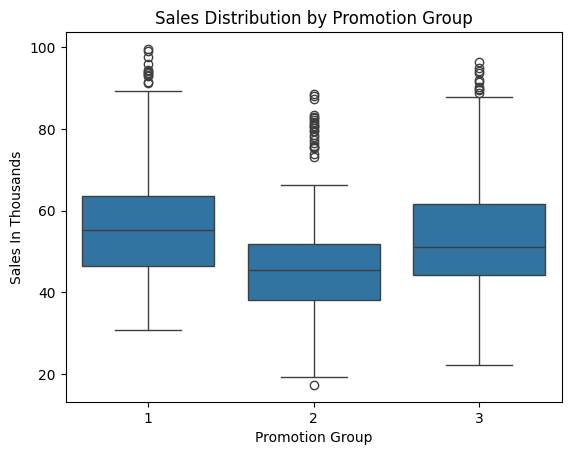

In [9]:
sns.boxplot(
    x='Promotion',
    y='SalesInThousands',
    data=df
)

plt.title("Sales Distribution by Promotion Group")
plt.xlabel("Promotion Group")
plt.ylabel("Sales In Thousands")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_8692\1135020923.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(


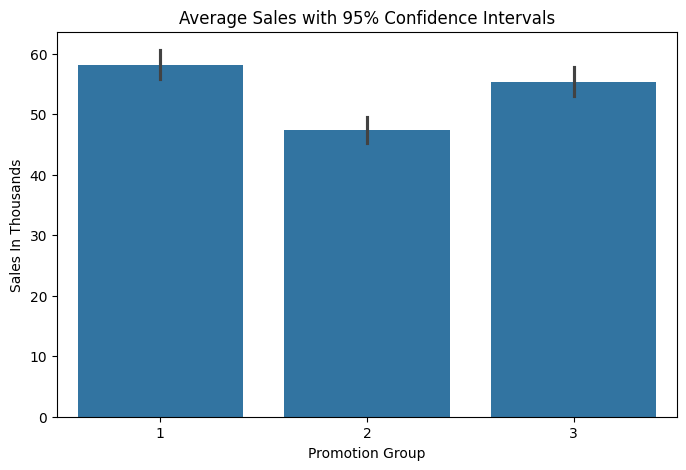

In [18]:

plt.figure(figsize=(8,5))

sns.barplot(
    x='Promotion',
    y='SalesInThousands',
    data=df,
    ci=95
)

plt.title("Average Sales with 95% Confidence Intervals")
plt.xlabel("Promotion Group")
plt.ylabel("Sales In Thousands")

plt.show()

The confidence interval plot shows that Promotion 2 generated lower average sales compared to Promotions 1 and 3.

The error bars for Promotion 2 show limited overlap with the other groups, suggesting statistically significant differences.

# Hypothesis
H0: All promotions had the same average sales.  

μ1 = μ2 = μ3

H1: At least one promotion group has a different average sales value.

Not all μ are equal



# ANOVA

In [10]:

import scipy.stats as stats

In [11]:
promotion1 = df.loc[df['Promotion'] == 1, 'SalesInThousands']
promotion2 = df.loc[df['Promotion'] == 2, 'SalesInThousands']
promotion3 = df.loc[df['Promotion'] == 3, 'SalesInThousands']




In [12]:

f_stat, p_value = stats.f_oneway(promotion1, promotion2, promotion3)

print(f"F_statistic: {f_stat}")
print(f"p_value: {p_value}")

F_statistic: 21.953485793080674
p_value: 6.765849261408834e-10


 
p_value: 6.765849261408834e-10 < 0.05

Since the p-value is less than 0.05, we reject the null hypothesis.

ANOVA results showed a statistically significant difference among promotion groups (p < 0.001).


# Tukey HSD:

In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [14]:
tukey = pairwise_tukeyhsd(endog=df['SalesInThousands'],groups=df['Promotion'],alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


### business conclusion: 

Tukey HSD analysis showed that Promotion 2 performed significantly worse than Promotions 1 and 3.

No statistically significant difference was found between Promotions 1 and 3.

